# Rectified Flow
The problem here is to learn an ODE  $\dot{Z}_t=v(Z_t,t)$  to transfer data from  $π_0$  to  $π_1$ , where both $π_0$  and $π_1$  are unknown and empirically observed through a set of points.

The velocity field  $v(z,t)$  in rectified flow can be fitted with either kernel method or deep neural networks. This tutorial illustrates the use of a neural network.

Shape of the samples: torch.Size([10000, 2]) torch.Size([10000, 2])


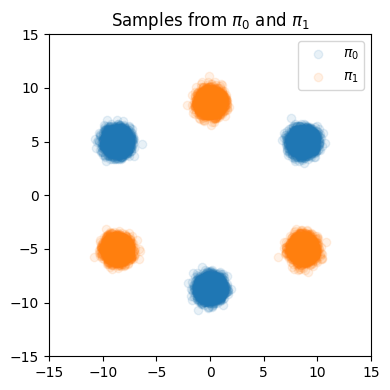

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.distributions import Normal, Categorical
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions.mixture_same_family import MixtureSameFamily
import matplotlib.pyplot as plt
import torch.nn.functional as F

D = 10.
M = D+5
VAR = 0.3
DOT_SIZE = 4
COMP = 3

initial_mix = Categorical(torch.tensor([1/COMP for i in range(COMP)]))
initial_comp = MultivariateNormal(torch.tensor([[D * np.sqrt(3) / 2., D / 2.], [-D * np.sqrt(3) / 2., D / 2.], [0.0, - D * np.sqrt(3) / 2.]]).float(), VAR * torch.stack([torch.eye(2) for i in range(COMP)]))
initial_model = MixtureSameFamily(initial_mix, initial_comp)
samples_0 = initial_model.sample([10000])

target_mix = Categorical(torch.tensor([1/COMP for i in range(COMP)]))
target_comp = MultivariateNormal(torch.tensor([[D * np.sqrt(3) / 2., - D / 2.], [-D * np.sqrt(3) / 2., - D / 2.], [0.0, D * np.sqrt(3) / 2.]]).float(), VAR * torch.stack([torch.eye(2) for i in range(COMP)]))
target_model = MixtureSameFamily(target_mix, target_comp)
samples_1 = target_model.sample([10000])
print('Shape of the samples:', samples_0.shape, samples_1.shape)

plt.figure(figsize=(4,4))
plt.xlim(-M,M)
plt.ylim(-M,M)
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
plt.scatter(samples_0[:, 0].cpu().numpy(), samples_0[:, 1].cpu().numpy(), alpha=0.1, label=r'$\pi_0$')
plt.scatter(samples_1[:, 0].cpu().numpy(), samples_1[:, 1].cpu().numpy(), alpha=0.1, label=r'$\pi_1$')
plt.legend()
plt.savefig("prove1.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()


## Define the Flow Model
Given empirical observations of $X_0\sim \pi_0$ and $X_1\sim \pi_1$, 
the rectified flow induced from $(X_0,X_1)$ 
is an ordinary differentiable model (ODE)
on time $t\in[0,1]$, 
$$
d Z_t = v^X(Z_t, t) d t, 
$$
which $v$ is set in a way that ensures that $Z_1$ follows $\pi_1$ when $Z_0 \sim \pi_0$. Let $X_t = t X_1 + (1-t)X_0$ be the linear interpolation of $X_0$ and $X_1$. Then $v$ is given by 
$$
v^X(z,t) = \mathbb{E}[X_1 - X_0 ~|~ X_t = z  ] =  \arg\min_{v} \int_0^1 \mathbb{E}[|| X_1-X_0 - v(X_t,t) ||^2] \mathrm{d} t,
$$ 
where the (conditional) expectation is w.r.t. the joint distribution of $(X_0,X_1)$.

We parameterize $v^X(z,t)$ with a 3-layer neural network.

In [2]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_num=100):
        super().__init__()
        self.fc1 = nn.Linear(input_dim+1, hidden_num, bias=True)
        self.fc2 = nn.Linear(hidden_num, hidden_num, bias=True)
        self.fc3 = nn.Linear(hidden_num, input_dim, bias=True)
        self.act = lambda x: torch.tanh(x)
    
    def forward(self, x_input, t):
        inputs = torch.cat([x_input, t], dim=1)
        x = self.fc1(inputs)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)

        return x

Then we define the rectfied flow class.

In [3]:
class RectifiedFlow():
  def __init__(self, model=None, num_steps=1000):
    self.model = model
    self.N = num_steps
  
  def get_train_tuple(self, z0=None, z1=None):
    t = torch.rand((z1.shape[0], 1))
    z_t =  t * z1 + (1.-t) * z0
    target = z1 - z0 
        
    return z_t, t, target

  @torch.no_grad()
  def sample_ode(self, z0=None, N=None):
    ### NOTE: Use Euler method to sample from the learned flow
    if N is None:
      N = self.N    
    dt = 1./N
    traj = [] # to store the trajectory
    z = z0.detach().clone()
    batchsize = z.shape[0]
    
    traj.append(z.detach().clone())
    for i in range(N):
      t = torch.ones((batchsize,1)) * i / N
      pred = self.model(z, t)
      z = z.detach().clone() + pred * dt
      
      traj.append(z.detach().clone())

    return traj

## Define the training method and other misc. code
We define the training method here. The loss function is:
$$
\min_{\theta} 
\int_0^1 E_{X_0 \sim \pi_0, X_1 \sim \pi_1} \left [ {||( X_1 - X_0) - v_\theta\big (X_t,~ t\big)||}^2
\right ] \text{d}t, 
~~~~~\text{with}~~~~
X_t = t X_1 + (1-t) X_0.
$$

In [4]:
def train_rectified_flow(rectified_flow, optimizer, pairs, batchsize, inner_iters):
  loss_curve = []
  for i in range(inner_iters+1):
    optimizer.zero_grad()
    indices = torch.randperm(len(pairs))[:batchsize]
    batch = pairs[indices]
    z0 = batch[:, 0].detach().clone()
    z1 = batch[:, 1].detach().clone()
    z_t, t, target = rectified_flow.get_train_tuple(z0=z0, z1=z1)

    pred = rectified_flow.model(z_t, t)
    loss = (target - pred).view(pred.shape[0], -1).abs().pow(2).sum(dim=1)
    loss = loss.mean()
    loss.backward()
    
    optimizer.step()
    loss_curve.append(np.log(loss.item())) ## to store the loss curve

  return rectified_flow, loss_curve

Misc. code for plotting figures.

In [5]:
# @torch.no_grad()
# def draw_plot(rectified_flow, z0, z1, N=None):
#   traj = rectified_flow.sample_ode(z0=z0, N=N)
  
#   plt.figure(figsize=(4,4))
#   plt.xlim(-M,M)
#   plt.ylim(-M,M)
    
#   plt.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(), label=r'$\pi_1$', alpha=0.15)
#   plt.scatter(traj[0][:, 0].cpu().numpy(), traj[0][:, 1].cpu().numpy(), label=r'$\pi_0$', alpha=0.15)
#   plt.scatter(traj[-1][:, 0].cpu().numpy(), traj[-1][:, 1].cpu().numpy(), label='Generated', alpha=0.15)
#   plt.legend()
#   plt.title('Distribution')
#   plt.tight_layout()

#   traj_particles = torch.stack(traj)
#   plt.figure(figsize=(4,4))
#   plt.xlim(-M,M)
#   plt.ylim(-M,M)
#   plt.axis('equal')
#   for i in range(30):
#     plt.plot(traj_particles[:, i, 0], traj_particles[:, i, 1])
#   plt.title('Transport Trajectory')
#   plt.tight_layout()
  
    
@torch.no_grad()
def draw_plot(rectified_flow, z0, z1, N=None, save_path="transport.pdf"):
    traj = rectified_flow.sample_ode(z0=z0, N=N)

    traj_particles = torch.stack(traj)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # 横向排列

    # ===== 左图：分布对比 =====
    axes[0].set_xlim(-M, M)
    axes[0].set_ylim(-M, M)

    axes[0].scatter(z1[:,0].cpu().numpy(),
                    z1[:,1].cpu().numpy(),
                    alpha=0.15,
                    label=r'$\pi_1$')

    axes[0].scatter(traj[0][:,0].cpu().numpy(),
                    traj[0][:,1].cpu().numpy(),
                    alpha=0.15,
                    label=r'$\pi_0$')

    axes[0].scatter(traj[-1][:,0].cpu().numpy(),
                    traj[-1][:,1].cpu().numpy(),
                    alpha=0.15,
                    label='Generated')

    axes[0].legend()
    axes[0].set_title('Distribution')

    # ===== 右图：轨迹 =====
    axes[1].set_xlim(-M, M)
    axes[1].set_ylim(-M, M)
    axes[1].set_aspect('equal')

    for i in range(min(30, traj_particles.shape[1])):
        axes[1].plot(traj_particles[:, i, 0].cpu().numpy(),
                     traj_particles[:, i, 1].cpu().numpy())

    axes[1].set_title('Transport Trajectory')

    plt.tight_layout()

    # ===== 保存为 PDF =====
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    

## 1-Rectified Flow
We start by generating the pairs $(X_0, X_1)$ by pooling randomly sampled points from ```sample_0``` and ```sample_1```. So $(X_0,X_1)$ forms an independent coupling of $\pi_0$ and $\pi_1$. 


In [6]:
x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))]
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))]
x_pairs = torch.stack([x_0, x_1], dim=1)
print(x_pairs.shape)

torch.Size([10000, 2, 2])


Text(0.5, 1.0, 'Training Loss Curve')

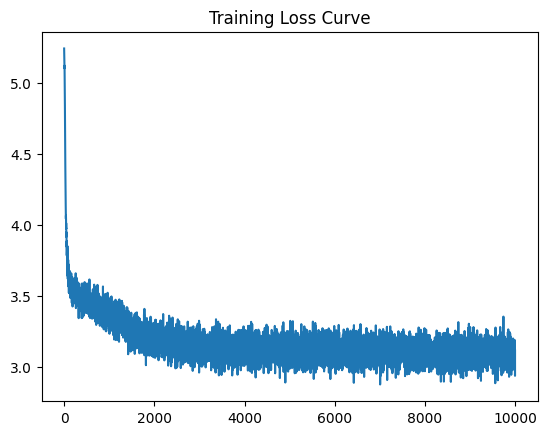

In [7]:
iterations = 10000
batchsize = 2048
input_dim = 2

rectified_flow_1 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)
optimizer = torch.optim.Adam(rectified_flow_1.model.parameters(), lr=5e-3)

rectified_flow_1, loss_curve = train_rectified_flow(rectified_flow_1, optimizer, x_pairs, batchsize, iterations)
plt.plot(np.linspace(0, iterations, iterations+1), loss_curve[:(iterations+1)])
plt.title('Training Loss Curve')

We run the Euler method to solve the ODE with $N=1000$ steps to generate samples from 1-Rectified Flow.

Orange dots = samples from $\pi_0$

Blue dots   = samples from $\pi_1$

Green dots  = samples from 1-Rectified Flow

1-Rectified Flow successfully learned a velocity field $v(Z_t, t)$ that can transport $\pi_0$ to $\pi_1$.

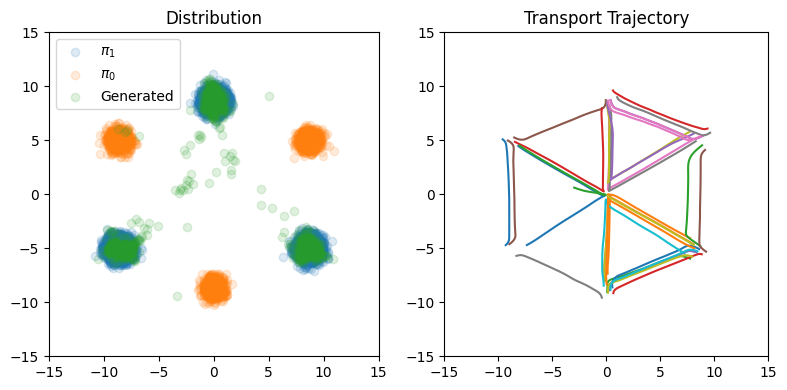

In [8]:
draw_plot(rectified_flow_1, z0=initial_model.sample([2000]), z1=samples_1.detach().clone(), N=100, save_path='prove2.pdf')

We can see that the trajectories above fit well on the trajectories of linear intepolation of data, but are "rewired" in the center when the trajectories are intersect. Hence, the resulting trajectories are either (almost)straight, or has a ">" shape. 

Due to the non-straight ">"-shape paths, if we simulate the ODE with a small step $N$, we would obtain poor performance, as shown below ($N=1$). 

## Reflow for 2-Rectified Flow
Now let's use the *reflow* procedure to get a straightened rectified flow, 
denoted as 2-Rectified Flow, by repeating the same procedure on with $(X_0,X_1)$ replaced by  $(Z_0^1, Z_1^1)$, where   $(Z_0^1, Z_1^1)$ is the coupling simulated from 1-Rectified Flow.  
Specifically, we randomly sample 10000 $Z_0^1$  and generate their corresponding  $Z_1^1$ by simulating 1-Rectified Flow.

In [9]:
z10 = samples_0.detach().clone()
traj = rectified_flow_1.sample_ode(z0=z10.detach().clone(), N=100)
z11 = traj[-1].detach().clone()
z_pairs = torch.stack([z10, z11], dim=1)
print(z_pairs.shape)

torch.Size([10000, 2, 2])


The coupling $(Z_0^1, Z_1^1)$ is now deterministic. The loss function is:
$$
\min_{\theta} 
\int_0^1 E_{(Z_0, Z_1) \sim (Z_0^1, Z_1^1)} \left [ {||( Z_1 - Z_0) - v_\theta\big (Z_t,~ t\big)||}^2
\right ] \text{d}t, 
~~~~~\text{with}~~~~
Z_t = t Z_1 + (1-t) Z_0.
$$

We create ```rectified_flow_2``` and its corresponding ```optimizer``` and traing 2-Rectified Flow with ```train_rectified_flow```. 

We use the model pretrained in 1-Rectified Flow to accelerate training.

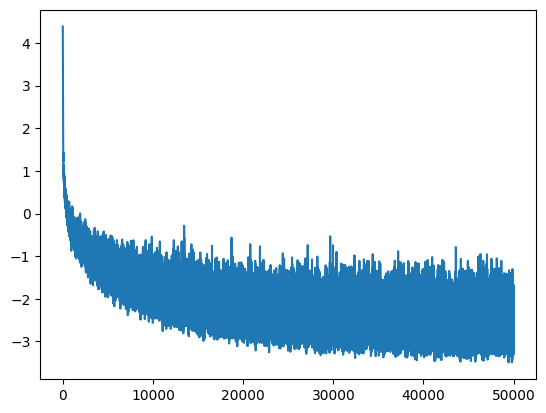

In [10]:
reflow_iterations = 50000

rectified_flow_2 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)
import copy 
rectified_flow_2.net = copy.deepcopy(rectified_flow_1) # we fine-tune the model from 1-Rectified Flow for faster training.
optimizer = torch.optim.Adam(rectified_flow_2.model.parameters(), lr=5e-3)

rectified_flow_2, loss_curve = train_rectified_flow(rectified_flow_2, optimizer, z_pairs, batchsize, reflow_iterations)
plt.plot(np.linspace(0, reflow_iterations, reflow_iterations+1), loss_curve[:(reflow_iterations+1)])

We run the Euler method to solve the ODE with $N=100$ steps to generate samples from 2-Rectified Flow.

2-Rectified Flow can also successfully learn a velocity field $v(Z_t, t)$ that can transport $\pi_0$ to $\pi_1$. 

The key point, however, is that the transport trajectory is now **straightened** and hence we would not lose much accuracy even if we solve the ODE with one Euler step ($N=1$). 

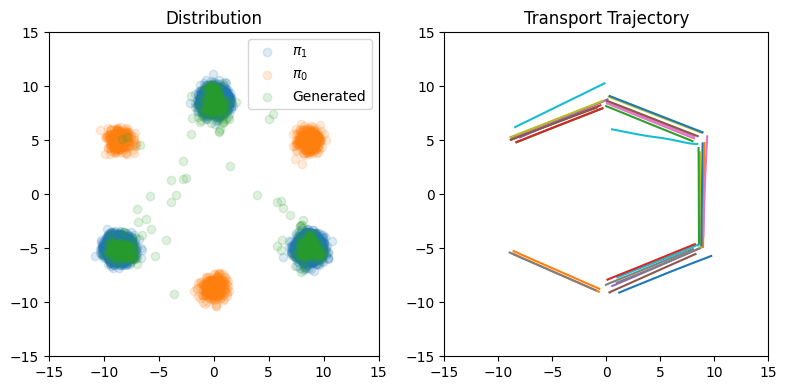

In [11]:
draw_plot(rectified_flow_2, z0=initial_model.sample([1000]), z1=samples_1.detach().clone(), save_path='prove3.pdf')

So below is the result when we solve the ODE with $N=1$ Euler step to generate samples from 2-Rectified Flow. 

With the **straightened** trajectory, we get almost perfect results with only  one-step generation! Thanks to the power of **Reflow** !

More croncretely, the output of the model is now $Z_1 = Z_0 + v(Z_0, 0)$. 

Effectively, we have trained a one-step model, by using ODE as an intermediate step. 

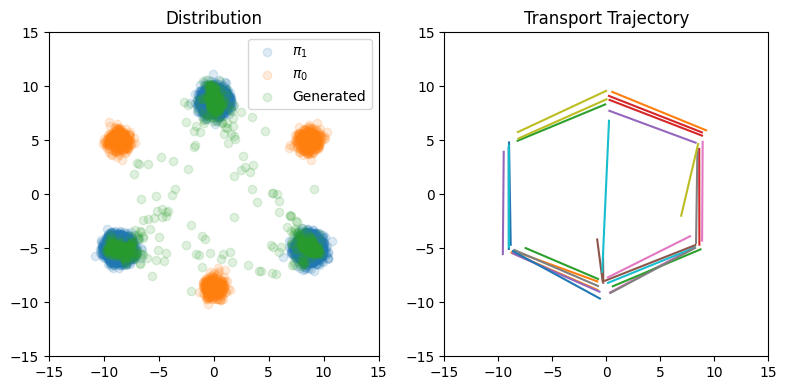

In [12]:
draw_plot(rectified_flow_2, z0=initial_model.sample([1000]), z1=samples_1.detach().clone(), N=1)

# Watermarked-Flow

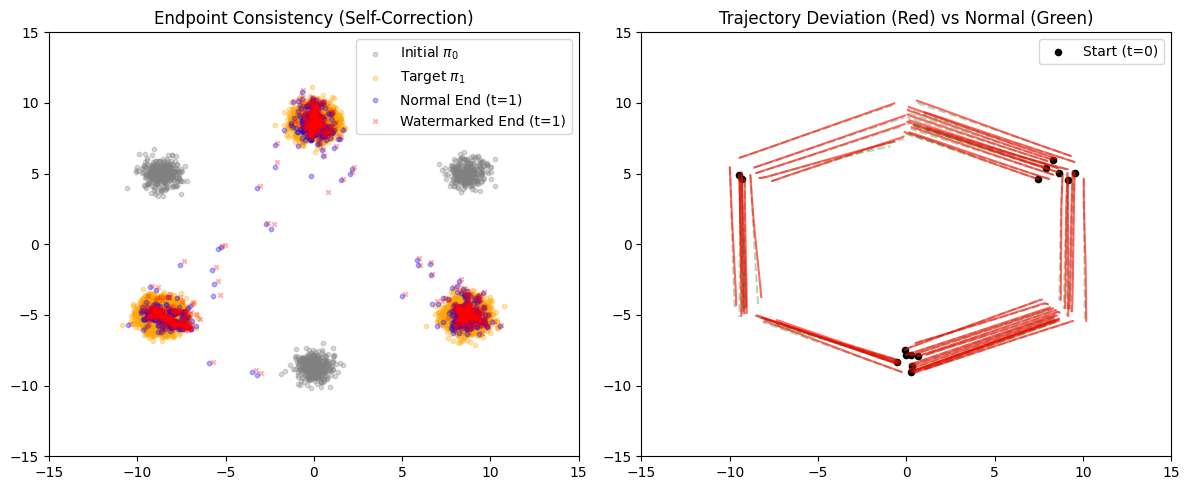

In [13]:
@torch.no_grad()
def draw_watermark_plot(rectified_flow, z0, z1, strength=0.5, watermark_vec=None):
    if watermark_vec is None:
        # 定义一个特定的方向作为水印特征向量（例如向右上方偏移）
        watermark_vec = torch.tensor([[0.3, 0.3]]).to(z0.device)

    # --- 1. 模拟正常采样 ---
    N = 1000
    dt = 1.0 / N
    traj_normal = [z0.detach().clone()]
    z_n = z0.detach().clone()
    for i in range(N):
        t = torch.ones((z_n.shape[0], 1)).to(z0.device) * i / N
        pred = rectified_flow.model(z_n, t)
        z_n = z_n + pred * dt
        traj_normal.append(z_n.detach().clone())
    traj_normal = torch.stack(traj_normal)

    # --- 2. 模拟带水印采样 (Parabolic Weight) ---
    traj_wm = [z0.detach().clone()]
    z_w = z0.detach().clone()
    for i in range(N):
        t_val = i / N
        t_tensor = torch.ones((z_w.shape[0], 1)).to(z0.device) * t_val
        
        # 抛物线权重 4*t*(1-t)
        weight = 4 * t_val * (1 - t_val)
        
        pred = rectified_flow.model(z_w, t_tensor)
        # 注入扰动
        v_modified = pred + strength * weight * watermark_vec
        
        z_w = z_w + v_modified * dt
        traj_wm.append(z_w.detach().clone())
    traj_wm = torch.stack(traj_wm)

    # --- 3. 绘图 ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # 左图：分布对比 (验证终点自修复)
    ax[0].set_xlim(-M, M); ax[0].set_ylim(-M, M)
    
    # 绘制初始分布 pi_0 (浅蓝色背景)
    ax[0].scatter(z0[:, 0].cpu(), z0[:, 1].cpu(), label=r'Initial $\pi_0$', alpha=0.3, c='gray', s=10)
    # 绘制真实目标点 z1 (作为参考标准)
    ax[0].scatter(z1[:, 0].cpu(), z1[:, 1].cpu(), label=r'Target $\pi_1$', alpha=0.3, c='orange', s=10)
    # 绘制正常生成的终点
    ax[0].scatter(traj_normal[-1, :, 0].cpu(), traj_normal[-1, :, 1].cpu(), 
                  label='Normal End (t=1)', alpha=0.3, c='blue', s=10)
    ax[0].scatter(traj_wm[-1, :, 0].cpu(), traj_wm[-1, :, 1].cpu(), 
                  label='Watermarked End (t=1)', alpha=0.3, c='red', marker='x', s=10)
    ax[0].set_title("Endpoint Consistency (Self-Correction)")
    ax[0].legend()

    # 右图：轨迹对比 (验证中间偏移)
    ax[1].set_xlim(-M, M); ax[1].set_ylim(-M, M)
    for i in range(50): # 绘制前15个粒子的对比
        # 正常路径用灰色虚线
        ax[1].plot(traj_normal[:, i, 0].cpu(), traj_normal[:, i, 1].cpu(), 'g--', alpha=0.3)
        # 水印路径用实线
        ax[1].plot(traj_wm[:, i, 0].cpu(), traj_wm[:, i, 1].cpu(), 'r-', alpha=0.6)
    
    # 标注起始点和中点的偏移
    ax[1].scatter(traj_wm[0, :15, 0].cpu(), traj_wm[0, :15, 1].cpu(), c='black', s=20, label='Start (t=0)')
    ax[1].set_title("Trajectory Deviation (Red) vs Normal (Green)")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig('prove.pdf')
    plt.show()

# 调用
draw_watermark_plot(rectified_flow_2, z0=initial_model.sample([1000]), z1=samples_1.detach().clone(), strength=0.5)

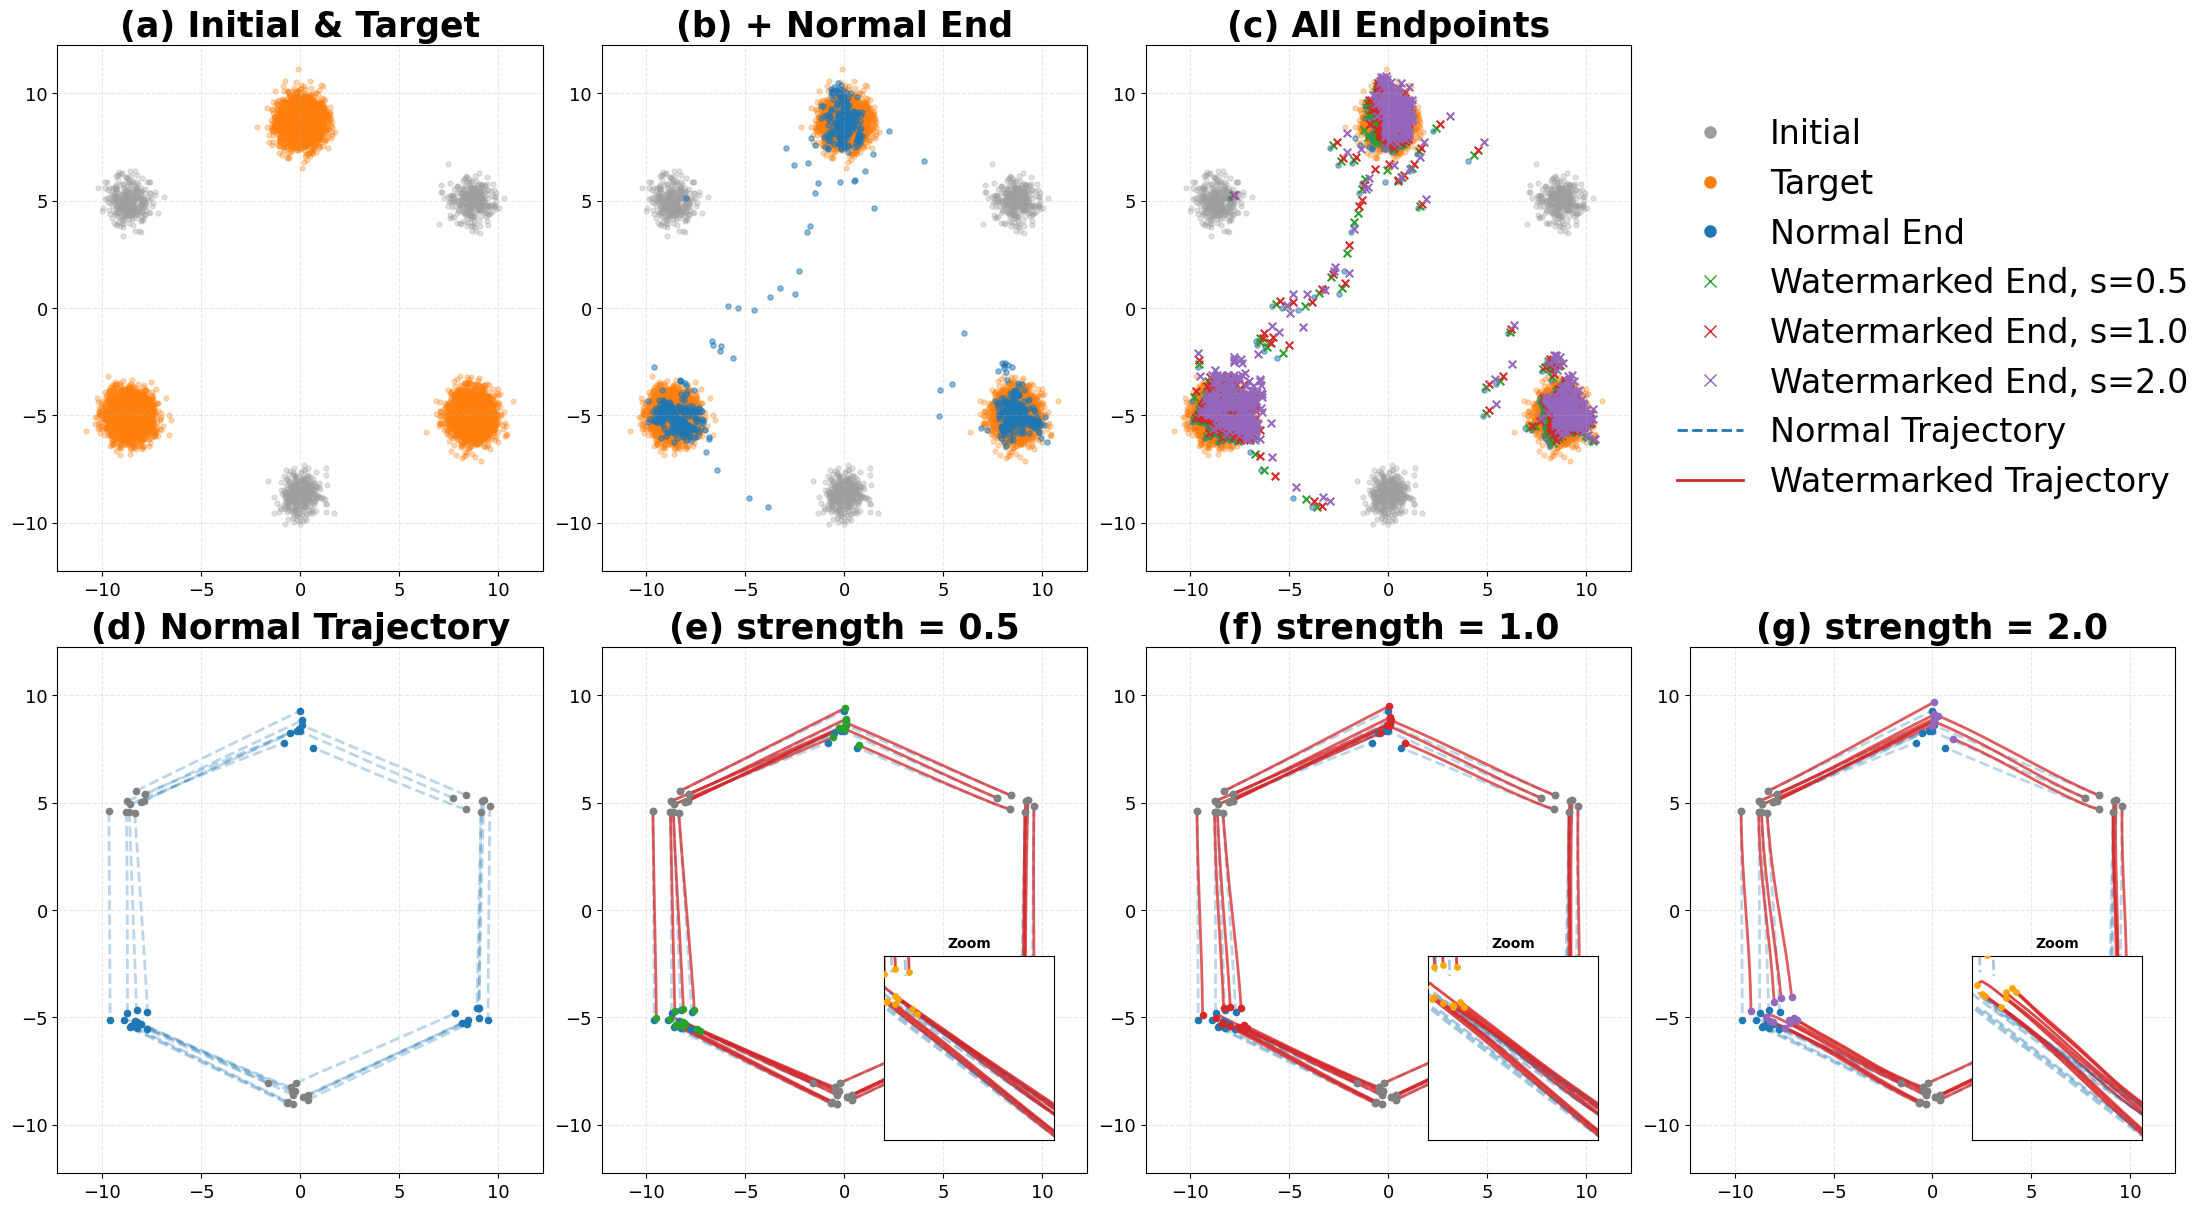

In [ ]:
@torch.no_grad()
def draw_watermark_plot_topconf_v5(rectified_flow, z0, z1,
                                   strength_list=[0.5, 1.0, 2.0],
                                   watermark_vec=None):

    import torch
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib.lines import Line2D
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    # =========================
    # Global Style
    # =========================
    mpl.rcParams.update({
        "font.size": 15,
        "axes.titlesize": 25,
        "axes.labelsize": 16,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "legend.fontsize": 24,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "lines.linewidth": 2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    device = z0.device

    if watermark_vec is None:
        watermark_vec = torch.tensor(
            [0.3] * z0.shape[1],
            device=device
        ).unsqueeze(0)

    N = 1000
    dt = 1.0 / N

    # =========================
    # 1. Normal trajectory
    # =========================
    traj_normal = torch.zeros(N+1, *z0.shape, device=device)
    traj_normal[0] = z0
    z_n = z0.clone()

    for i in range(N):
        t_val = i / N
        t_tensor = torch.full((z_n.shape[0], 1), t_val, device=device)
        pred = rectified_flow.model(z_n, t_tensor)
        z_n = z_n + pred * dt
        traj_normal[i+1] = z_n

    # =========================
    # 2. Watermarked trajectories
    # =========================
    trajs_wm = []
    for s in strength_list:
        traj_wm = torch.zeros(N+1, *z0.shape, device=device)
        traj_wm[0] = z0
        z_w = z0.clone()

        for i in range(N):
            t_val = i / N
            t_tensor = torch.full((z_w.shape[0], 1), t_val, device=device)
            weight = 4 * t_val * (1 - t_val)
            pred = rectified_flow.model(z_w, t_tensor)
            z_w = z_w + (pred + s * weight * watermark_vec) * dt
            traj_wm[i+1] = z_w

        trajs_wm.append(traj_wm)

    # =========================
    # Axis range
    # =========================
    all_points = torch.cat(
        [z0, z1, traj_normal[-1]] +
        [traj[-1] for traj in trajs_wm],
        dim=0
    )
    M = all_points.abs().max().item() * 1.1

    # =========================
    # Layout (2x4)
    # =========================
    fig = plt.figure(figsize=(22, 12), constrained_layout=True)
    gs = fig.add_gridspec(2, 4)

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])
    ax_legend = fig.add_subplot(gs[0, 3])

    ax_d = fig.add_subplot(gs[1, 0])
    ax_e = fig.add_subplot(gs[1, 1])
    ax_f = fig.add_subplot(gs[1, 2])
    ax_g = fig.add_subplot(gs[1, 3])

    # =========================
    # -------- First Row --------
    # =========================
    ax_a.scatter(z0[:,0].cpu(), z0[:,1].cpu(), color='#9e9e9e', alpha=0.3, s=12)
    ax_a.scatter(z1[:,0].cpu(), z1[:,1].cpu(), color='#ff7f0e', alpha=0.3, s=12)
    ax_a.set_title("(a) Initial & Target")

    ax_b.scatter(z0[:,0].cpu(), z0[:,1].cpu(), color='#9e9e9e', alpha=0.3, s=12)
    ax_b.scatter(z1[:,0].cpu(), z1[:,1].cpu(), color='#ff7f0e', alpha=0.3, s=12)
    ax_b.scatter(traj_normal[-1,:,0].cpu(),
                 traj_normal[-1,:,1].cpu(),
                 color='#1f77b4', alpha=0.5, s=14)
    ax_b.set_title("(b) + Normal End")

    ax_c.scatter(z0[:,0].cpu(), z0[:,1].cpu(), color='#9e9e9e', alpha=0.3, s=12)
    ax_c.scatter(z1[:,0].cpu(), z1[:,1].cpu(), color='#ff7f0e', alpha=0.3, s=12)
    ax_c.scatter(traj_normal[-1,:,0].cpu(),
                 traj_normal[-1,:,1].cpu(),
                 color='#1f77b4', alpha=0.5, s=14)

    # 第一行 Watermarked End 用绿色、红色、紫色
    wm_colors = ['#2ca02c', '#d62728', '#9467bd']  # green, red, purple
    for idx in range(len(strength_list)):
        ax_c.scatter(trajs_wm[idx][-1,:,0].cpu(),
                     trajs_wm[idx][-1,:,1].cpu(),
                     marker='x', s=30, linewidths=1.5, color=wm_colors[idx])

    ax_c.set_title("(c) All Endpoints")

    for ax in [ax_a, ax_b, ax_c]:
        ax.set_xlim(-M, M)
        ax.set_ylim(-M, M)
        ax.grid(True, linestyle='--', alpha=0.3)

    # =========================
    # -------- Second Row --------
    # =========================
    num_traj = min(30, z0.shape[0])

    def plot_traj(ax, traj_main, title, add_inset=False, color_index=None):
        for i in range(num_traj):
            # 正常轨迹线
            ax.plot(traj_normal[:,i,0].cpu(),
                    traj_normal[:,i,1].cpu(),
                    linestyle='--',
                    color='#1f77b4',
                    alpha=0.3)
            # 起点灰色
            ax.scatter(traj_normal[0,i,0].cpu(),
                        traj_normal[0,i,1].cpu(),
                        color='gray', s=20, zorder=5)
            # 终点
            ax.scatter(traj_normal[-1,i,0].cpu(),
                        traj_normal[-1,i,1].cpu(),
                        color='#1f77b4', s=20, zorder=5)
            
        if traj_main is not None:
            for i in range(num_traj):
                # 水印轨迹线统一红色
                ax.plot(traj_main[:,i,0].cpu(),
                        traj_main[:,i,1].cpu(),
                        color='#d62728',
                        alpha=0.75)
                # 起点灰色
                ax.scatter(traj_main[0,i,0].cpu(),
                           traj_main[0,i,1].cpu(),
                           color='gray', s=20, zorder=5)
                # 终点橙色
                ax.scatter(traj_main[-1,i,0].cpu(),
                           traj_main[-1,i,1].cpu(),
                           color=wm_colors[color_index], s=20, zorder=5)

        ax.set_xlim(-M, M)
        ax.set_ylim(-M, M)
        ax.set_title(title)
        ax.grid(True, linestyle='--', alpha=0.3)

        if add_inset:
            axins = inset_axes(ax, width="35%", height="35%",
                               loc='lower right', borderpad=1)
            axins.set_xlim(-0.7 * M, -0.15 * M)
            axins.set_ylim(-0.7 * M, -0.35 * M)

            for i in range(num_traj):
                axins.plot(traj_normal[:,i,0].cpu(),
                           traj_normal[:,i,1].cpu(),
                           linestyle='--',
                           color='#1f77b4',
                           alpha=0.4)
                axins.plot(traj_main[:,i,0].cpu(),
                           traj_main[:,i,1].cpu(),
                           color='#d62728',
                           alpha=0.85)
                axins.scatter(traj_main[0,i,0].cpu(),
                              traj_main[0,i,1].cpu(),
                              color='gray', s=15, zorder=5)
                axins.scatter(traj_main[-1,i,0].cpu(),
                              traj_main[-1,i,1].cpu(),
                              color=wm_colors[color_index], s=15, zorder=5)

            axins.set_xticks([])
            axins.set_yticks([])
            axins.set_title("Zoom", fontsize=10)

    plot_traj(ax_d, None, "(d) Normal Trajectory")
    plot_traj(ax_e, trajs_wm[0], "(e) strength = 0.5", add_inset=True, color_index=0)
    plot_traj(ax_f, trajs_wm[1], "(f) strength = 1.0", add_inset=True, color_index=1)
    plot_traj(ax_g, trajs_wm[2], "(g) strength = 2.0", add_inset=True, color_index=2)

    # =========================
    # Legend
    # =========================
    ax_legend.axis("off")

    legend_elements = [
        Line2D([0], [0], marker='o', color='#9e9e9e',
               linestyle='None', markersize=8, label='Initial'),
        Line2D([0], [0], marker='o', color='#ff7f0e',
               linestyle='None', markersize=8, label='Target'),
        Line2D([0], [0], marker='o', color='#1f77b4',
               linestyle='None', markersize=8, label='Normal End'),
    ]

    for idx, s in enumerate(strength_list):
        legend_elements.append(
            Line2D([0], [0], marker='x', color=wm_colors[idx],
                   linestyle='None', markersize=8,
                   label=f'Watermarked End, s={s}')
        )

    legend_elements.append(Line2D([0], [0], linestyle='--', color='#1f77b4',
                                  linewidth=2, label='Normal Trajectory'))
    legend_elements.append(Line2D([0], [0], linestyle='-', color='#d62728',
                                  linewidth=2, label='Watermarked Trajectory'))

    ax_legend.legend(handles=legend_elements,
                     loc='center',
                     frameon=False)

    plt.savefig('prove.pdf')
    plt.show()
    

draw_watermark_plot_topconf_v5(rectified_flow_2, z0=initial_model.sample([1000]), z1=samples_1.detach().clone(), strength_list=[0.5, 1.0, 2.0])